# Model training and evaluation

Predicting whether a customer responds to the campaign (14.9% positive
rate) - class-weighted Logistic Regression vs Random Forest vs Gradient
Boosting, stratified split, evaluated with PR-AUC/ROC-AUC rather than
accuracy alone. This is the classification stage the original project's
markdown said it wanted to build but never did ("it would be better to
build a classification model... classifying optoutduration") - here, on
a real, non-leaky target.

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              average_precision_score, roc_curve, precision_recall_curve)

customers = pd.read_csv('outputs/customers_clean.csv')
customers['Education_enc'] = LabelEncoder().fit_transform(customers['Education'])
customers['Marital_enc'] = LabelEncoder().fit_transform(customers['Marital_Status'])

with open('outputs/feature_list.json') as f:
    feature_cols = json.load(f)

X = customers[feature_cols]
y = customers['Response']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, stratify = y, random_state = 42)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((1662, 13),
 (554, 13),
 np.float64(0.15042117930204574),
 np.float64(0.14981949458483754))

In [2]:
models = {
    'Logistic Regression (balanced)': Pipeline([('scale', StandardScaler()), ('clf', LogisticRegression(class_weight = 'balanced', max_iter = 2000, random_state = 42))]),
    'Random Forest (balanced)': Pipeline([('scale', StandardScaler()), ('clf', RandomForestClassifier(n_estimators = 300, class_weight = 'balanced', random_state = 42, n_jobs = -1))]),
    'Gradient Boosting': Pipeline([('scale', StandardScaler()), ('clf', GradientBoostingClassifier(random_state = 42))]),
}

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv = cv, scoring = 'average_precision', n_jobs = -1)
    cv_results[name] = scores
    print(f'{name:32s} PR-AUC = {scores.mean():.3f} (+/- {scores.std():.3f})')

Logistic Regression (balanced)   PR-AUC = 0.465 (+/- 0.054)


Random Forest (balanced)         PR-AUC = 0.573 (+/- 0.057)


Gradient Boosting                PR-AUC = 0.542 (+/- 0.060)


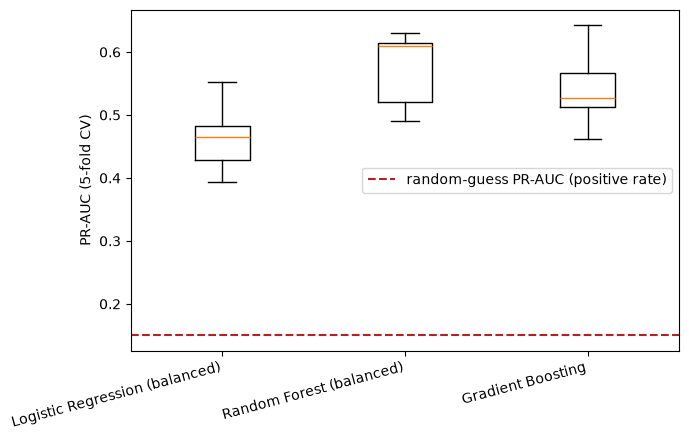

In [3]:
fig, ax = plt.subplots(figsize = (7, 4.5))
ax.boxplot(cv_results.values(), tick_labels = cv_results.keys())
ax.axhline(y_train.mean(), color = 'firebrick', linestyle = '--', label = 'random-guess PR-AUC (positive rate)')
ax.set_ylabel('PR-AUC (5-fold CV)')
ax.legend()
plt.xticks(rotation = 15, ha = 'right')
plt.tight_layout()
plt.savefig('outputs/cv_model_comparison.png', dpi = 120)
plt.show()

In [4]:
best_name = max(cv_results, key = lambda k: cv_results[k].mean())
best_model = models[best_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f'best model: {best_name}')
print(classification_report(y_test, y_pred, target_names = ['no response', 'responded'], digits = 3))
print(f'test PR-AUC: {average_precision_score(y_test, y_prob):.3f}')
print(f'test ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}')

best model: Random Forest (balanced)
              precision    recall  f1-score   support

 no response      0.908     0.924     0.916       471
   responded      0.520     0.470     0.494        83

    accuracy                          0.856       554
   macro avg      0.714     0.697     0.705       554
weighted avg      0.850     0.856     0.853       554

test PR-AUC: 0.521
test ROC-AUC: 0.858


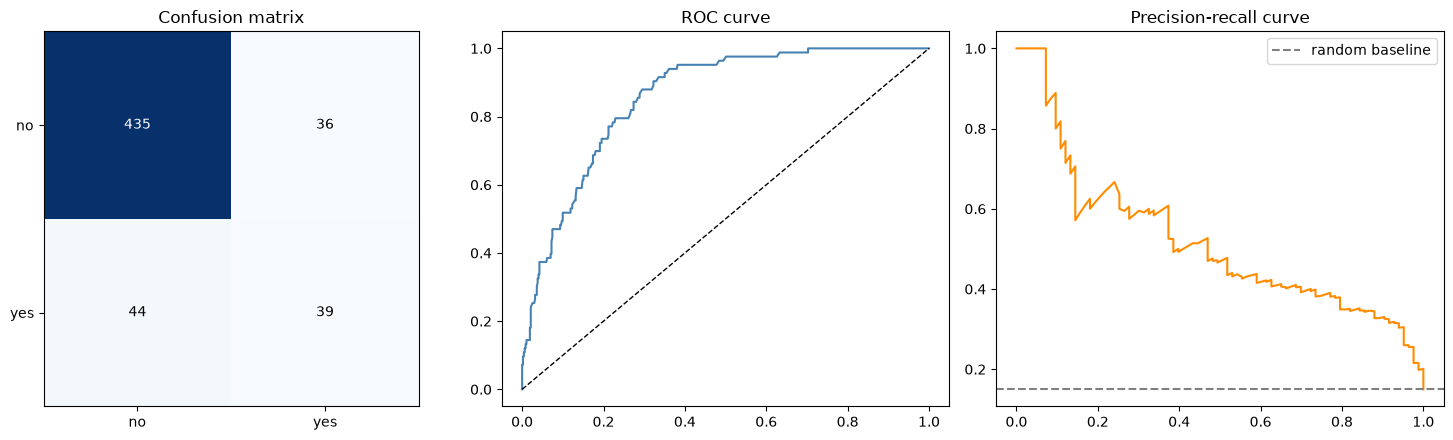

In [5]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4.5))

cm = confusion_matrix(y_test, y_pred)
axes[0].imshow(cm, cmap = 'Blues')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha = 'center', va = 'center', color = 'white' if cm[i, j] > cm.max() / 2 else 'black')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['no', 'yes'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['no', 'yes'])
axes[0].set_title('Confusion matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color = 'steelblue')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth = 1)
axes[1].set_title('ROC curve')

prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[2].plot(rec, prec, color = 'darkorange')
axes[2].axhline(y_test.mean(), color = 'gray', linestyle = '--', label = 'random baseline')
axes[2].set_title('Precision-recall curve')
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/model_evaluation.png', dpi = 120)
plt.show()

In [6]:
os.makedirs('outputs', exist_ok = True)
results = {
    'best_model': best_name,
    'cv_pr_auc_mean': {k: float(v.mean()) for k, v in cv_results.items()},
    'test_pr_auc': float(average_precision_score(y_test, y_prob)),
    'test_roc_auc': float(roc_auc_score(y_test, y_prob)),
    'test_positive_rate': float(y_test.mean()),
}
with open('outputs/model_results.json', 'w') as f:
    json.dump(results, f, indent = 2)

results

{'best_model': 'Random Forest (balanced)',
 'cv_pr_auc_mean': {'Logistic Regression (balanced)': 0.46465623979903076,
  'Random Forest (balanced)': 0.5726866682638396,
  'Gradient Boosting': 0.542377858837974},
 'test_pr_auc': 0.5205323827269572,
 'test_roc_auc': 0.8581843296753894,
 'test_positive_rate': 0.14981949458483754}